In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
membership = pd.read_excel("../Dataset/Membership.xlsx")
viewhistory = pd.read_excel("../Dataset/View_History.xlsx")
usermapping = pd.read_excel("../Dataset/User_Mapping.xlsx")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

> 연령 별 인구 분포 (전체, 인증, 미인증)

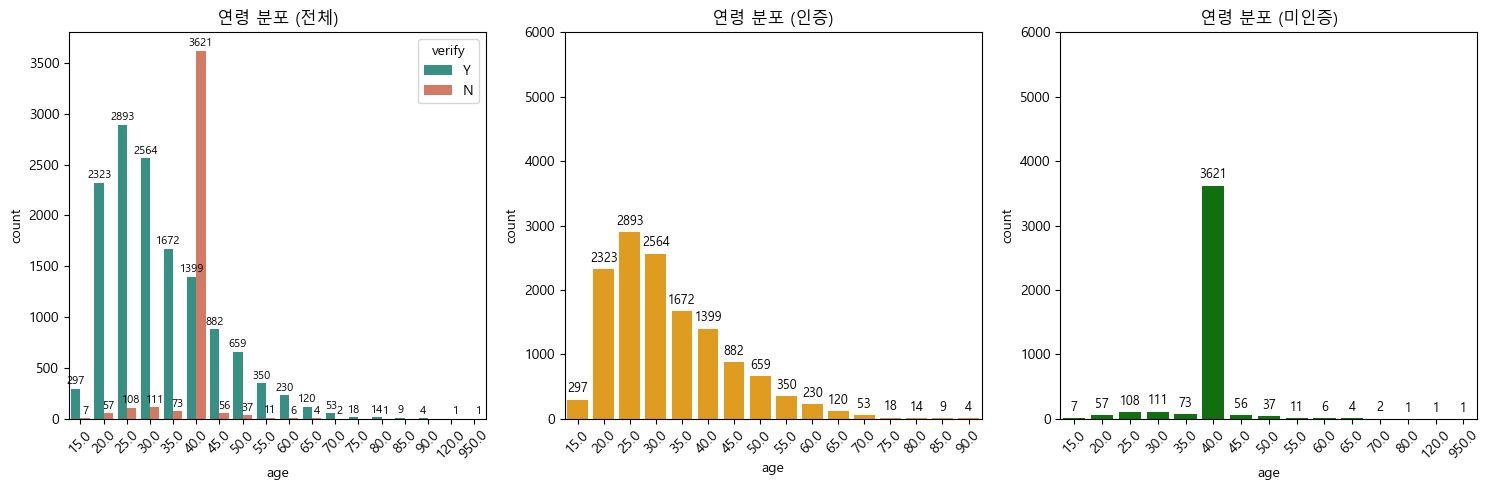

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age Distribution (Entire)
sns.countplot(
    data=membership[membership["is_user_verified"].isin(["Y", "N"])],
    x="age",
    hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
    ax=axes[0]
)
axes[0].set_title("연령 분포 (전체)")
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].legend(title="verify")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=1, fontsize=8)

# Age Distribution (Verified)
sns.countplot(data=membership[membership["is_user_verified"] == "Y"], x="age", ax=axes[1], color="orange")
axes[1].set_title("연령 분포 (인증)")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
axes[1].set_ylim(0, 6000)
plt.tight_layout()

# Age Distribution (Non-Verified)
sns.countplot(data=membership[membership["is_user_verified"] == "N"], x="age", ax=axes[2], color="green")
axes[2].set_title("연령 분포 (미인증)")
axes[2].tick_params(axis="x", labelrotation=45)
axes[2].bar_label(axes[2].containers[0], padding=3, fontsize=9)
axes[2].set_ylim(0, 6000)
plt.tight_layout()

> 결제 기기 별 인증 분포 (인증/미인증)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10132\3012880590.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, rotation=0)


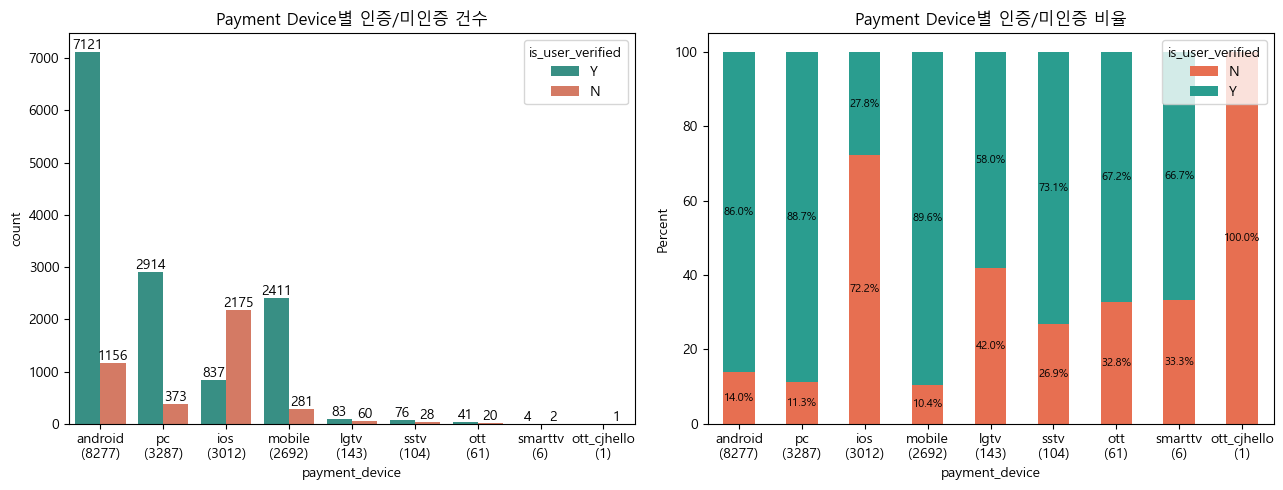

In [ ]:
plot_data = membership[membership["is_user_verified"].isin(["Y", "N"])].reset_index().copy()

device_order = plot_data["payment_device"].value_counts().index
device_counts = plot_data["payment_device"].value_counts()
x_labels = [f"{device}\n({device_counts[device]})" for device in device_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = sns.countplot(
    data=plot_data,
    x="payment_device",
    hue="is_user_verified",
    order=device_order,
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
    ax=axes[0]
)
ax1.set_title("Payment Device별 인증/미인증 건수")
ax1.set_xticklabels(x_labels, rotation=0)
for container in ax1.containers:
    ax1.bar_label(container, fmt="%d")

ratio_table = pd.crosstab(
    plot_data["payment_device"],
    plot_data["is_user_verified"],
    normalize="index"
).reindex(device_order) * 100

ax2 = ratio_table.plot(
    kind="bar",
    stacked=True,
    color=["#E76F51", "#2A9D8F"],
    ax=axes[1]
)
ax2.set_title("Payment Device별 인증/미인증 비율")
ax2.set_ylabel("Percent")
ax2.set_xticklabels(x_labels, rotation=0)

for i, row in enumerate(ratio_table.itertuples(index=False)):
    y = 0
    for value in row:
        if value > 0:
            ax2.text(i, y + value / 2, f"{value:.1f}%", ha="center", va="center", fontsize=8)
            y += value

plt.tight_layout()
plt.show()


> 결제 기기와 연령 별 인증/미인증 분포 확인

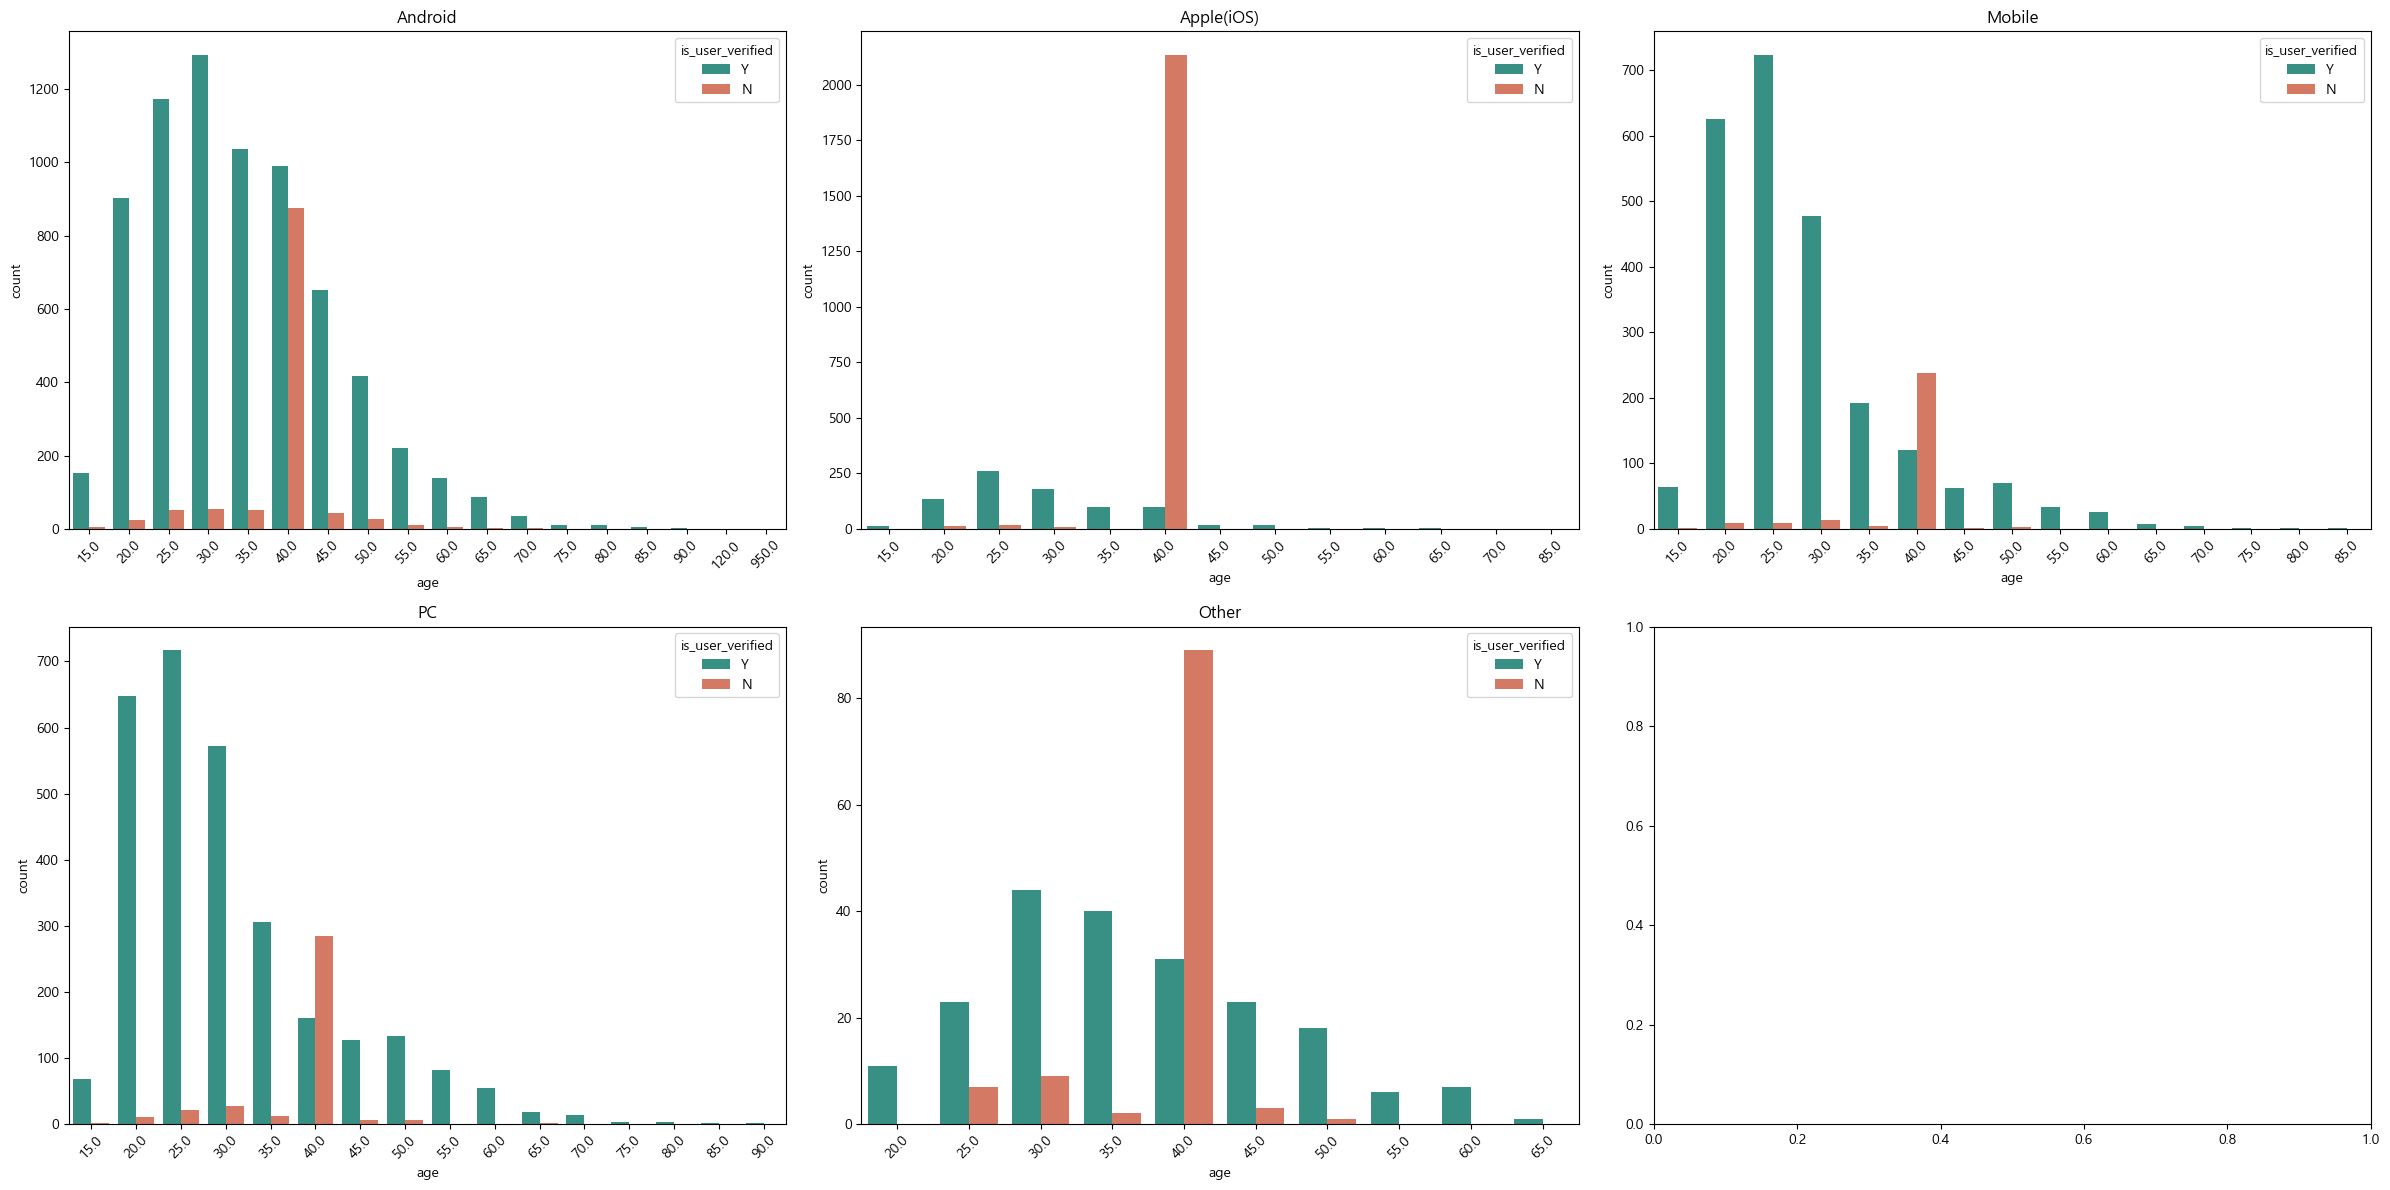

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(24, 12))

ax0 = sns.countplot(
	data=membership[
		(membership["is_user_verified"].isin(["Y", "N"])) & (membership["payment_device"] == "android")],
	x="age",
	hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
	ax=axes[0, 0]
)
ax0.tick_params(axis="x", labelrotation=45)
ax0.set_title("Android")

ax1 = sns.countplot(
	data=membership[
		(membership["is_user_verified"].isin(["Y", "N"])) & (membership["payment_device"] == "ios")],
	x="age",
	hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
	ax=axes[0, 1]
)
ax1.tick_params(axis="x", labelrotation=45)
ax1.set_title("Apple(iOS)")

ax2 = sns.countplot(
	data=membership[
		(membership["is_user_verified"].isin(["Y", "N"])) & (membership["payment_device"] == "mobile")],
	x="age",
	hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
	ax=axes[0, 2]
)
ax2.tick_params(axis="x", labelrotation=45)
ax2.set_title("Mobile")

ax3 = sns.countplot(
	data=membership[
		(membership["is_user_verified"].isin(["Y", "N"])) & (membership["payment_device"] == "pc")],
	x="age",
	hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
	ax=axes[1, 0]
)
ax3.tick_params(axis="x", labelrotation=45)
ax3.set_title("PC")

ax4 = sns.countplot(
	data=membership[
		(membership["is_user_verified"].isin(["Y", "N"])) &
		(~membership["payment_device"].isin(["android", "ios", "mobile", "pc"]))],
	x="age",
	hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
	ax=axes[1, 1]
)
ax4.tick_params(axis="x", labelrotation=45)
ax4.set_title("Other")

plt.tight_layout()